### *EDDY MonIToring and Characterization from High rEsoLution alTimetry*

In [1]:
import glob
import sys
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")
from datetime import datetime,date,timedelta
from netCDF4 import Dataset
from scipy.interpolate import griddata
#from swot_functions import *
#from detection_functions import *


###**********************************###
perc_thr=40
central_tol=0.6
Rmin=5
Amin=0.01
shape_err=85
###**********************************###


import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature


def make_curved_map2(lat_max=-50,figsize=(6,6),lafont=14,facecol='w'):
    fig = plt.figure(figsize=figsize)
    ax = plt.subplot(1, 1,1, projection=ccrs.SouthPolarStereo(),fc=facecol)
    ax.set_extent([-180, 180, -90, -50], ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='grey', edgecolor='k', zorder=19)
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.2, zorder=20)#50mmedium 10m high
    gl = ax.gridlines(draw_labels=True, rotate_labels=False,
                      x_inline=False, y_inline=False, linestyle='-', alpha=1)
    ax.set_extent([-180, 180, -90, lat_max], ccrs.PlateCarree())
    gl.xlabel_style = {'size': lafont}   # longitude labels
    gl.ylabel_style = {'size': lafont}   # latitude labels
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)
    for lat in [-55,-60,-65,-70]:
        ax.text(
            0, lat,               # lon=45°
            f"{-lat}°S",
            transform=ccrs.PlateCarree(),
            fontsize=8,
            ha='left',
            va='center',
            rotation=0,
            zorder=20000)
    return fig,ax


def OrdinalToDatetime(ordinal):
    plaindate = date.fromordinal(int(ordinal))
    date_time = datetime.combine(plaindate, datetime.min.time())
    return date_time + timedelta(days=ordinal-int(ordinal))

In [2]:
#for the southern hemishpere
path_data='../polar-swot-detection/2024-2025-v3.0/South/'

#either use each slices
extraction_names=['slice-0-2425-v3_0',
                  'slice-1-2425-v3_0',
                  'slice-2-2425-v3_0',
                  'slice-3-2425-v3_0',
                  'slice-4-2425-v3_0',
                  'slice-5-2425-v3_0',
                  'slice-6-2425-v3_0',
                  'slice-7-2425-v3_0',
                  'slice-8-2425-v3_0'
                  ]
#or use the concatenated version (no raw detection for this one)
extraction_names=['all_slices-2425-v3_0',
                  ]


In [5]:
# read the detection and associated parameters
lon_all_allareas={}
lat_all_allareas={}
contour_lon_all_allareas={}
contour_lat_all_allareas={}
ipass_all_allareas={}
pol_all_allareas={}
juld_all_allareas={}
cycle_all_allareas={}
cycles_avail=[]
r_all_allareas={}
v_all_allareas={}
a_all_allareas={}
ice_all_allareas={}
Rd_all_allareas={}
depth_all_allareas={}

for extraction_name in extraction_names:
    print(extraction_name)
    path_save=path_data+'detection_'+extraction_name+'/'
    
    if extraction_name=='all_slices-2425-v3_0':
        namefile='post-proc-v2-all_slices-data-detection_pt_40_ct_0.6_Rmin_05_Amin_0.01_shapeerror_85.nc'
    else:
        namefile='post-proc-data-detection_'+'pt_'+str(perc_thr).zfill(2)+'_ct_'+str(central_tol).zfill(3)+'_Rmin_'+str(Rmin).zfill(2)+'_Amin_'+str(Amin).zfill(2)+'_shapeerror_'+str(shape_err).zfill(2)+'.nc'
    nc=Dataset(path_save+namefile)
    lon_all_allareas[extraction_name]=nc['lon'][:]
    lat_all_allareas[extraction_name]=nc['lat'][:]
    contour_lon_all_allareas[extraction_name]=nc['clon'][:] #need to save this one
    contour_lat_all_allareas[extraction_name]=nc['clat'][:]
    ipass_all_allareas[extraction_name]=nc['ipass'][:]
    pol_all_allareas[extraction_name]=nc['pol'][:]
    juld_all_allareas[extraction_name]=nc['juld'][:]
    cycle_all_allareas[extraction_name]=nc['cycle'][:]
    r_all_allareas[extraction_name]=nc['r'][:]
    v_all_allareas[extraction_name]=nc['v'][:]
    a_all_allareas[extraction_name]=nc['a'][:]
    nc.close()

    namefile3='topo_'+'pt_'+str(perc_thr).zfill(2)+'_ct_'+str(central_tol).zfill(3)+'_Rmin_'+str(Rmin).zfill(2)+'_Amin_'+str(Amin).zfill(2)+'_shapeerror_'+str(shape_err).zfill(2)+'.nc'
    nc=Dataset(path_save+namefile3)
    depth_all_allareas[extraction_name]=nc['depth'][:]
    nc.close()
    namefile3='ice-detection_'+'pt_'+str(perc_thr).zfill(2)+'_ct_'+str(central_tol).zfill(3)+'_Rmin_'+str(Rmin).zfill(2)+'_Amin_'+str(Amin).zfill(2)+'_shapeerror_'+str(shape_err).zfill(2)+'.nc'
    nc=Dataset(path_save+namefile3)
    ice_all_allareas[extraction_name]=nc['ice_conc'][:]
    nc.close()
    namefile3='Rd-detection_'+'pt_'+str(perc_thr).zfill(2)+'_ct_'+str(central_tol).zfill(3)+'_Rmin_'+str(Rmin).zfill(2)+'_Amin_'+str(Amin).zfill(2)+'_shapeerror_'+str(shape_err).zfill(2)+'.nc'
    nc=Dataset(path_save+namefile3)
    Rd_all_allareas[extraction_name]=nc['Rd'][:]
    nc.close()
    cycles_avail.append(np.unique(cycle_all_allareas[extraction_name]))
cycles_avail=np.unique(np.concatenate(cycles_avail))        

    

all_slices-2425-v3_0


plot cycle #8 from 14/12/2023 to 13/01/2025
all_slices-2425-v3_0
3044 eddies in this domain for this cycle


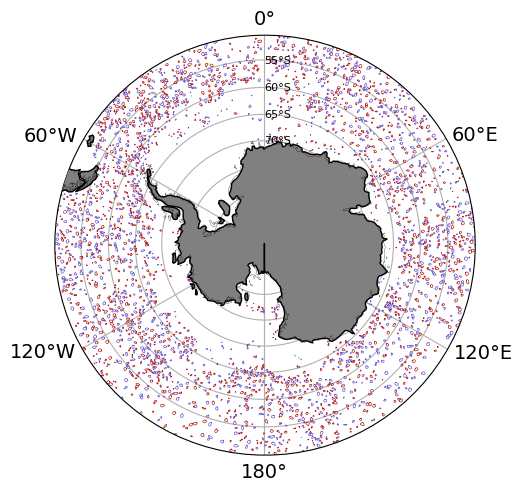

In [6]:
# plot the detection for one cycle
icycle=2

take_cycle=cycle_all_allareas[extraction_names[0]]==cycles_avail[icycle]
minjuld=np.nanmin(juld_all_allareas[extraction_names[0]][take_cycle])
maxjuld=np.nanmax(juld_all_allareas[extraction_names[0]][take_cycle])
print('plot cycle #{} from '.format(int(cycles_avail[icycle]))+OrdinalToDatetime(int(minjuld-1721424.5)).strftime("%d/%m/%Y")+' to '+OrdinalToDatetime(int(maxjuld-1721424.5)).strftime("%d/%m/%Y"))



#remove coastal and ice-covered eddies
min_depth=-500
max_ice_conc=0.15



fig, ax = make_curved_map2()
for extraction_name in extraction_names[:]:
    print(extraction_name)
    take_cycle=cycle_all_allareas[extraction_name]==cycles_avail[icycle]
    icount=0
    for ieddy in range(len(lon_all_allareas[extraction_name])):

        if take_cycle[ieddy]==False:continue

        if depth_all_allareas[extraction_name][ieddy]>min_depth or np.isnan(depth_all_allareas[extraction_name][ieddy]):
            continue

        if ice_all_allareas[extraction_name][ieddy]>max_ice_conc:continue



        if pol_all_allareas[extraction_name][ieddy]==-1:thiscol='slateblue'
        elif pol_all_allareas[extraction_name][ieddy]==+1:thiscol='firebrick'    

        plt.plot(contour_lon_all_allareas[extraction_name][ieddy]-360,
                    contour_lat_all_allareas[extraction_name][ieddy],
                    '-',c=thiscol,lw=0.5,
                    transform=ccrs.PlateCarree())


        icount+=1
    print('{} eddies in this domain for this cycle'.format(icount))


plt.subplots_adjust(bottom=0.25,top=0.95)
plt.show()

In [7]:
#if we want to load all the raw detection data for one subdomain

extraction_name='slice-8-2425-v3_0' #choose yours
path_save=path_data+'detection_'+extraction_name+'/raw_detection/'


print('load detection')


#loop because of the chunks
namefiles=glob.glob(path_save+'*detection*.nc');namefiles.sort()
lon_all=[]
lat_all=[]
juld_all=[]
cycle_all=[]
r_all=[]
v_all=[]
a_all=[]
perc_gaps_all=[]
pol_all=[]
contour_lon_all=[]
contour_lat_all=[]
ipass_all=[]
cycles_avail=[]


for namefile in namefiles:
    #print(namefile)
    nc=Dataset(namefile)
    lon_all.append(nc['lon'][:])
    lat_all.append(nc['lat'][:])
    juld_all.append(nc['juld'][:])
    cycle_all.append(nc['cycle'][:])
    r_all.append(nc['r'][:])
    v_all.append(nc['v'][:])
    a_all.append(nc['a'][:])
    perc_gaps_all.append(nc['perc_gaps'][:])
    pol_all.append(nc['pol'][:])
    contour_lon_all.append(nc['clon'][:])
    contour_lat_all.append(nc['clat'][:])
    ipass_all.append(nc['ipass'][:])
    cycles_avail.append(np.unique(nc['cycle'][:]))
    nc.close()

lon_all=np.concatenate(lon_all,axis=0)
lat_all=np.concatenate(lat_all,axis=0)
juld_all=np.concatenate(juld_all,axis=0)
cycle_all=np.concatenate(cycle_all,axis=0)
r_all=np.concatenate(r_all,axis=0)
v_all=np.concatenate(v_all,axis=0)
a_all=np.concatenate(a_all,axis=0)
perc_gaps_all=np.concatenate(perc_gaps_all,axis=0)
pol_all=np.concatenate(pol_all,axis=0)
contour_lon_all=np.concatenate(contour_lon_all,axis=0)
contour_lat_all=np.concatenate(contour_lat_all,axis=0)
ipass_all=np.concatenate(ipass_all,axis=0)
cycles_avail=np.unique(np.concatenate(cycles_avail,axis=0))
lon_all=np.where(lon_all>180,lon_all-360,lon_all)

#plot the detection for each cycle
"""for icycle in range(len(cycles_avail)):
    take_cycle=cycle_all==cycles_avail[icycle]
    plt.plot(lon_all[take_cycle],lat_all[take_cycle],'ok')
    plt.show()"""

print('done')

load detection
done
